In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importing dataset
df=pd.read_csv("C:\\Debraj\\Projects\\Air Pollution\\Dataset\\Air pollution .csv")
df.head()


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",11-09-2025 21:00:00,11.654054,92.734055,SO2,NaN,NaN,NaN
1,India,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",11-09-2025 21:00:00,11.654054,92.734055,CO,NaN,NaN,NaN
2,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",11-09-2025 21:00:00,16.515083,80.518167,PM2.5,14.0,43.0,26.0
3,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",11-09-2025 21:00:00,16.515083,80.518167,SO2,11.0,15.0,13.0
4,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",11-09-2025 21:00:00,16.515083,80.518167,CO,13.0,20.0,19.0


array([[<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'pollutant_min'}>,
        <Axes: title={'center': 'pollutant_max'}>],
       [<Axes: title={'center': 'pollutant_avg'}>, <Axes: >]],
      dtype=object)

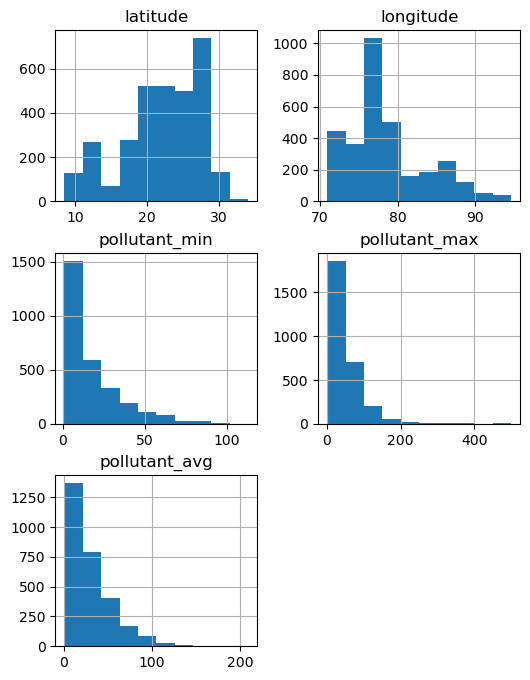

In [4]:
#data cleaning
df.hist(bins=10,figsize=(6,8))

In [5]:
#handling NaN Values
df.fillna(0,inplace=True)
city_means=df.groupby("city")["pollutant_avg"].median().reset_index()
zero_pollution_cities = city_means[city_means["pollutant_avg"] == 0]
cities_to_drop=zero_pollution_cities["city"].tolist()
df["pollutant_avg"] = df["pollutant_avg"].replace(0, np.nan)

cities_to_drop

['Baghpat',
 'Bihar Sharif',
 'Buxar',
 'Byasanagar',
 'Chhal',
 'Dewas',
 'Jhunjhunu',
 'Khurja',
 'Kollam',
 'Koppal',
 'Manguraha',
 'Milupara',
 'Ramanagara',
 'Salem',
 'Sri Vijaya Puram',
 'Tensa',
 'Thanjavur',
 'Tumakuru',
 'Tumidih']

In [6]:
#removing the cities that have zero pollution averages values
df1=df.copy()
for i in cities_to_drop:
    itd=df[df["city"] == i].index
    df1.drop(itd,inplace=True)
df1=df1.reset_index()
cities=df1["city"].unique().tolist()
pollutants=df1["pollutant_id"].unique().tolist()
cities

['Amaravati',
 'Anantapur',
 'Chittoor',
 'Byrnihat',
 'Guwahati',
 'Gaya',
 'Katihar',
 'Bhagalpur',
 'Chhapra',
 'Motihari',
 'Munger',
 'Muzaffarpur',
 'Patna',
 'Aurangabad',
 'Begusarai',
 'Bettiah',
 'Rajamahendravaram',
 'Tirumala',
 'Tirupati',
 'Vijayawada',
 'Naharlagun',
 'Nagaon',
 'Nalbari',
 'Sivasagar',
 'Chandigarh',
 'Bhilai',
 'Delhi',
 'Bilaspur',
 'Purnia',
 'Rajgir',
 'Samastipur',
 'Sasaram',
 'Ahmedabad',
 'Ankleshwar',
 'Gandhinagar',
 'Nandesari',
 'Vapi',
 'Gurugram',
 'Panchgaon',
 'Bengaluru',
 'Baddi',
 'Srinagar',
 'Dhanbad',
 'Jorapokhar',
 'Vijayapura',
 'Yadgir',
 'Eloor',
 'Thiruvananthapuram',
 'Bidar',
 'Chikkaballapur',
 'Chikkamagaluru',
 'Hubballi',
 'Kalaburagi',
 'Thrissur',
 'Bhopal',
 'Gwalior',
 'Davanagere',
 'Dharwad',
 'Hassan',
 'Mangalore',
 'Mysuru',
 'Indore',
 'Amravati',
 'Sagar',
 'Satna',
 'Singrauli',
 'Ahmednagar',
 'Badlapur',
 'Bhiwandi',
 'Boisar',
 'Chandrapur',
 'Jalna',
 'Kalyan',
 'Kolhapur',
 'Jabalpur',
 'Katni',
 'Pitha

In [7]:
#filling the NaN Values with city Averages

In [8]:
df2=df1.copy()
for i in cities:
    for j in pollutants:
        mask=(df2["city"]==i) & (df2["pollutant_id"]==j)
        mean=df2[mask]["pollutant_avg"].mean()
        df2.loc[mask,"pollutant_avg"]=df2.loc[mask,"pollutant_avg"].fillna(mean)

In [9]:
#Dropping the Rows That still have NaN values

In [10]:
indices=df2[df2['pollutant_avg'].isnull()].index
df2.drop(indices,inplace=True)
df2.isnull().sum()

index            0
country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64

In [11]:
pol=["pollutant_min","pollutant_max"]
for k in pol:    
    for i in cities:
        for j in pollutants:
            mask=(df2["city"]==i) & (df2["pollutant_id"]==j)
            mean=df2[mask][k].mean()
            df2.loc[mask,k]=df2.loc[mask,k].fillna(mean)

In [12]:
df2.isnull().sum()

index            0
country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64

In [13]:
#Data Cleaning is completed

array([[<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'pollutant_min'}>,
        <Axes: title={'center': 'pollutant_max'}>],
       [<Axes: title={'center': 'pollutant_avg'}>, <Axes: >]],
      dtype=object)

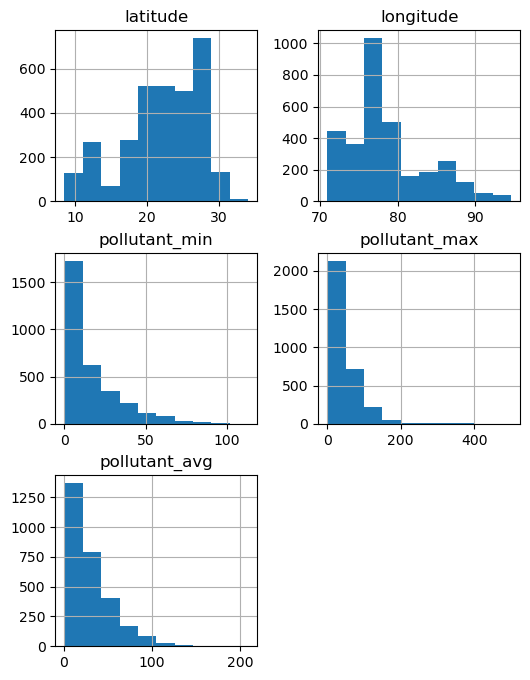

In [14]:
#extracting the result as a csv File
df.hist(bins=10,figsize=(6,8))

In [15]:
#-------------EDA---------------

In [16]:
df2["state"].replace("Jammu_and_Kashmir","Jammu and Kashmir Ladakh",inplace=True)
df2["state"].unique()

C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\2563024449.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["state"].replace("Jammu_and_Kashmir","Jammu and Kashmir Ladakh",inplace=True)


array(['Andhra_Pradesh', 'Assam', 'Bihar', 'Arunachal_Pradesh',
       'Chandigarh', 'Chhattisgarh', 'Delhi', 'Gujarat', 'Haryana',
       'Karnataka', 'Himachal Pradesh', 'Jammu and Kashmir Ladakh',
       'Jharkhand', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Nagaland',
       'Odisha', 'Rajasthan', 'Punjab', 'Sikkim', 'TamilNadu',
       'Telangana', 'Uttar_Pradesh', 'Tripura', 'Uttarakhand',
       'West_Bengal', 'Meghalaya'], dtype=object)

In [17]:
df2.to_csv("Air_Pollution_Cleaned2",index=True)

In [18]:
pollutants

['PM2.5', 'SO2', 'CO', 'NH3', 'OZONE', 'PM10', 'NO2']

In [19]:
df_grouped=df2.groupby(["state","pollutant_id"])["pollutant_avg"].mean().reset_index()
df_grouped.loc[df_grouped.groupby("pollutant_id")["pollutant_avg"].idxmax()]


,state,pollutant_id,pollutant_avg
73,Jharkhand,CO,50.5
63,Himachal Pradesh,NH3,10.0
74,Jharkhand,NO2,89.0
65,Himachal Pradesh,OZONE,44.0
66,Himachal Pradesh,PM10,109.0
89,Kerala,PM2.5,61.0
115,Nagaland,SO2,70.0


In [20]:
df_grouped=df2.groupby(["state","city","pollutant_id"])["pollutant_max"].mean().reset_index()
df_grouped.loc[df_grouped.groupby("pollutant_id")["pollutant_max"].idxmax()]


,state,city,pollutant_id,pollutant_max
848,Odisha,Keonjhar,CO,186.0
619,Maharashtra,Boisar,NH3,31.0
112,Bihar,Araria,NO2,199.0
485,Kerala,Thiruvananthapuram,OZONE,178.0
913,Punjab,Mandi Gobindgarh,PM10,490.0
442,Karnataka,Madikeri,PM2.5,500.0
419,Karnataka,Haveri,SO2,120.0


In [21]:
df_grouped=df2.groupby(["state","city","pollutant_id"])["pollutant_min"].mean().reset_index()
df_grouped.loc[df_grouped.groupby("pollutant_id")["pollutant_min"].idxmax()]


,state,city,pollutant_id,pollutant_min
171,Bihar,Katihar,CO,82.0
1509,West_Bengal,Siliguri,NH3,12.0
353,Jharkhand,Dhanbad,NO2,78.0
302,Gujarat,Ankleshwar,OZONE,51.0
656,Maharashtra,Kalyan,PM10,83.0
73,Assam,Byrnihat,PM2.5,83.0
419,Karnataka,Haveri,SO2,113.0


In [22]:
#Getting the correlation
import seaborn as sns

In [23]:
df5=pd.read_csv("C:\\Users\\bubai\\Projects\\City and pollutants.csv")
cols_df5=df5.columns.tolist()

<Axes: >

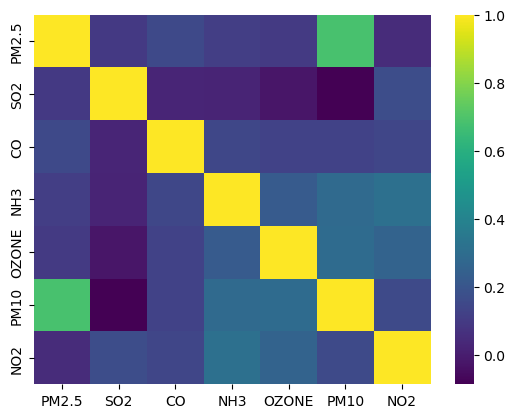

In [24]:
pollutants
corr_matrix=df5[pollutants].corr()
corr_matrix
sns.heatmap(df5[pollutants].corr(), cmap='viridis')

In [25]:
corr_matrix

,PM2.5,SO2,CO,NH3,OZONE,PM10,NO2
PM2.5,1.000000,0.094047,0.152042,0.109996,0.097673,0.683755,0.046014
SO2,0.094047,1.000000,0.025040,0.023070,-0.023750,-0.086981,0.166825
CO,0.152042,0.025040,1.000000,0.144524,0.127274,0.125626,0.141862
NH3,0.109996,0.023070,0.144524,1.000000,0.221750,0.285677,0.307909
OZONE,0.097673,-0.023750,0.127274,0.221750,1.000000,0.287432,0.255566
PM10,0.683755,-0.086981,0.125626,0.285677,0.287432,1.000000,0.156655
NO2,0.046014,0.166825,0.141862,0.307909,0.255566,0.156655,1.000000


C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\4154260691.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df2[["pollutant_min","pollutant_max","pollutant_avg"]],labels=["pollutant_min","pollutant_max","pollutant_avg"])


{'whiskers': [<matplotlib.lines.Line2D at 0x1dec3e79590>,
 'caps': [<matplotlib.lines.Line2D at 0x1dec3e79810>,
 'boxes': [<matplotlib.lines.Line2D at 0x1dec3e79450>,
 'medians': [<matplotlib.lines.Line2D at 0x1dec3e79a90>,
 'fliers': [<matplotlib.lines.Line2D at 0x1dec3e79bd0>,
 'means': []}

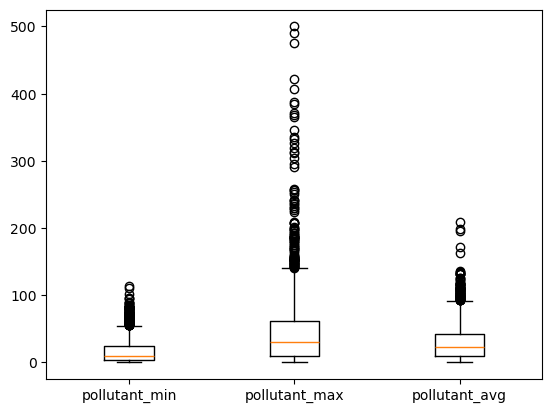

In [26]:
plt.boxplot(df2[["pollutant_min","pollutant_max","pollutant_avg"]],labels=["pollutant_min","pollutant_max","pollutant_avg"])

In [27]:
north=["Delhi","Haryana",
"Punjab",
"Himachal Pradesh",
"Jammu and Kashmir Ladakh",
"Uttarakhand",
"Chandigarh","Uttar_Pradesh"]

south=["Andhra_Pradesh",
"Karnataka",
"Kerala",
"TamilNadu",
"Telangana"]

east=["Bihar",
"Jharkhand",
"Odisha",
"West_Bengal",
"Assam",
"Arunachal_Pradesh",
"Nagaland",
"Tripura",
"Meghalaya",
"Sikkim"]

west=["Gujarat",
"Maharashtra",
"Rajasthan",
"Madhya Pradesh",
"Chhattisgarh"]

In [28]:
df2["Region"] = None
df2.loc[df2["state"].isin(west), "Region"] = "West"
df2.loc[df2["state"].isin(north), "Region"] = "North"
df2.loc[df2["state"].isin(south), "Region"] = "South"
df2.loc[df2["state"].isin(east), "Region"] = "East"

In [29]:
df2.to_csv("Air_Pollution_Cleaned5",index=True)

In [30]:
pm2=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="PM2.5"]
SO2 =df2[["Region","pollutant_avg"]][df["pollutant_id"]=="SO2"]
CO=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="CO"]
NH3=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="NH3"]
OZONE=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="OZONE"]
PM10= df2[["Region","pollutant_avg"]][df["pollutant_id"]=="PM10"]
NO2=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="NO2"]

pm2.head()

C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\1731852046.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pm2=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="PM2.5"]
C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\1731852046.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  SO2 =df2[["Region","pollutant_avg"]][df["pollutant_id"]=="SO2"]
C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\1731852046.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  CO=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="CO"]
C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\1731852046.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  NH3=df2[["Region","pollutant_avg"]][df["pollutant_id"]=="NH3"]
C:\Users\bubai\AppData\Local\Temp\ipykernel_21196\1731852046.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  OZONE=df2[["Region","p

,Region,pollutant_avg
2,South,19.0
17,East,5.0
26,East,1.0
27,East,5.0
29,East,66.0


In [31]:
pollutants
region_order = ["North", "South", "East", "West"]

Text(0.5, 1.0, 'pm2')

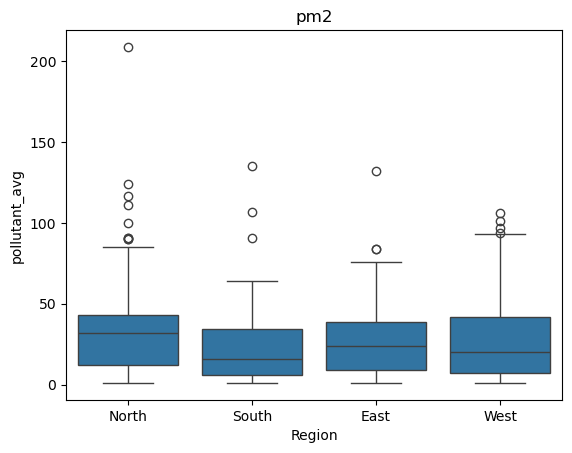

In [32]:
sns.boxplot(x="Region",y="pollutant_avg",data=pm2,order=region_order)
plt.title("pm2")

Text(0.5, 1.0, 'SO2')

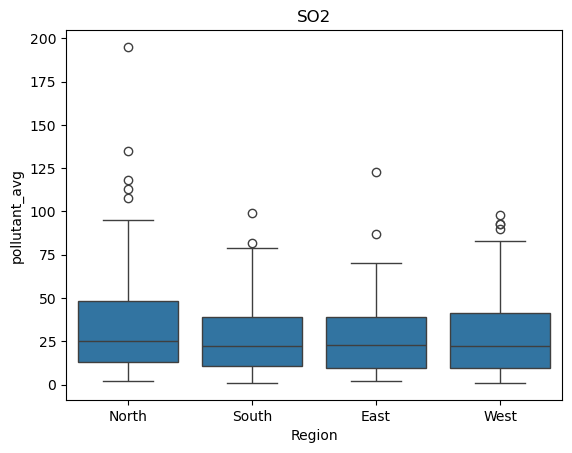

In [33]:
sns.boxplot(x="Region",y="pollutant_avg",data=SO2,order=region_order)
plt.title("SO2")

Text(0.5, 1.0, 'CO')

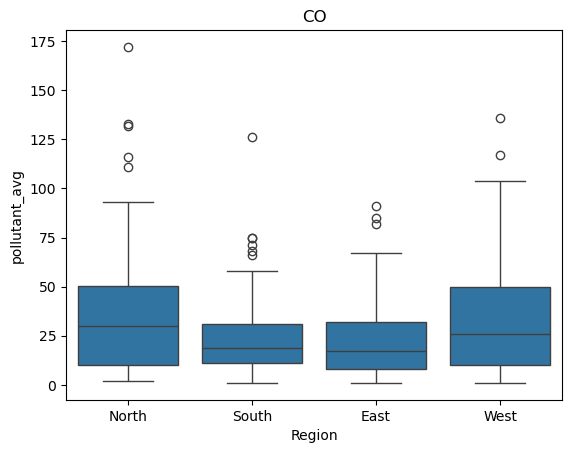

In [34]:
sns.boxplot(x="Region",y="pollutant_avg",data=CO,order=region_order)
plt.title("CO")

Text(0.5, 1.0, 'NH3')

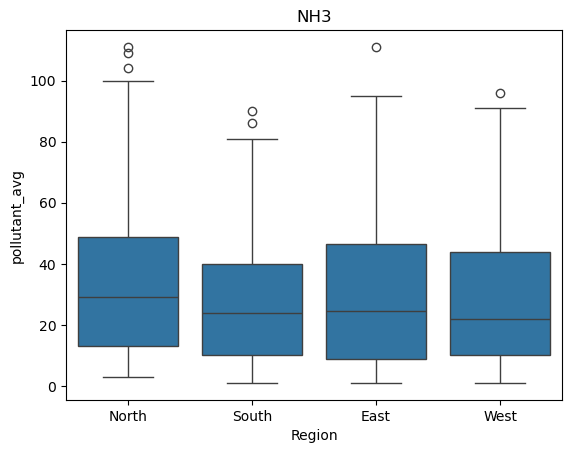

In [35]:
sns.boxplot(x="Region",y="pollutant_avg",data=NH3,order=region_order)
plt.title("NH3")

Text(0.5, 1.0, 'OZONE')

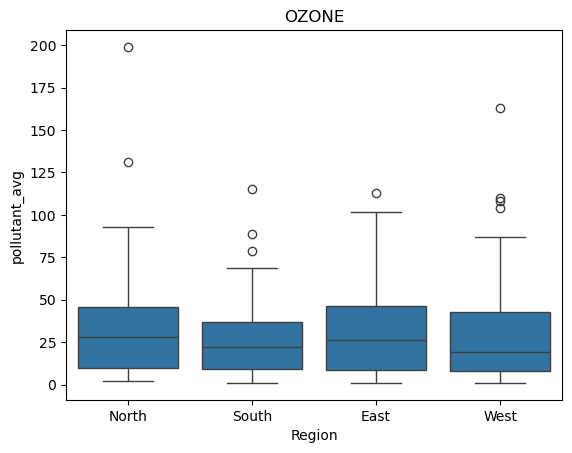

In [36]:
sns.boxplot(x="Region",y="pollutant_avg",data=OZONE,order=region_order)
plt.title("OZONE")

Text(0.5, 1.0, 'PM10')

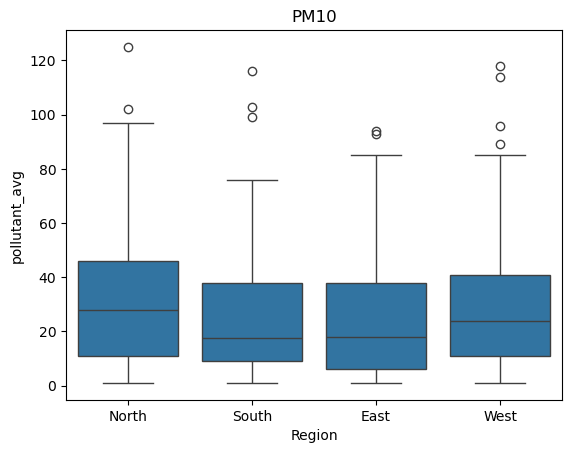

In [37]:
sns.boxplot(x="Region",y="pollutant_avg",data=PM10,order=region_order)
plt.title("PM10")

Text(0.5, 1.0, 'NO2')

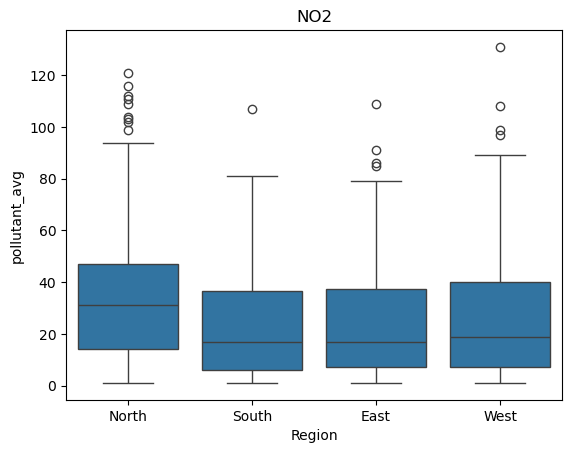

In [38]:

sns.boxplot(x="Region",y="pollutant_avg",data=NO2,order=region_order)
plt.title("NO2")

In [39]:
region_pollution = df2.groupby("Region")["pollutant_avg"].mean()

In [40]:
region_pollution

Region
East     27.374143
North    35.294598
South    25.469012
West     29.190352
Name: pollutant_avg, dtype: float64